Aluno: Afonso Henrique Guimarães de Oliveira


# CAPÍTULO 1: APRENDIZADO SUPERVISIONADO

Modelo de Machine Learning de crédito tendo em vista o histórico dos últimos clientes do banco. O objetivo é classificar um cliente em poor (provável mau pagador), standard (médio) ou good (provável bom pagador).

# Contexto

Você trabalha como cientista de dados em uma empresa financeira global. Ao longo dos anos, a empresa coletou informações bancárias básicas e reuniu uma grande quantidade de dados relacionados a crédito. A gerência deseja construir um sistema inteligente para segmentar as pessoas em faixas de pontuação de crédito, reduzindo assim o trabalho manual. (kaggle)

- ID:                                       Representa uma identificação única de um registro
- Customer_ID:                              Representa uma identificação única de uma pessoa
- Month:                                    Representa o mês do ano
- Name:                                     Representa o nome de uma pessoa
- Age:                                      Representa a idade da pessoa
- SSN:                                      Representa o número de seguridade social de uma pessoa
- Occupation:                               Representa a ocupação da pessoa
- Annual_Income:                            Representa a renda anual da pessoa
- Monthly_Inhand_Salary:                    Representa o salário base mensal de uma pessoa
- Num_Bank_Accounts:                        Representa o número de contas bancárias que uma pessoa possui
- Num_Credit_Card:                          Representa o número de outros cartões de crédito que uma pessoa possui
- Interest_Rate:                            Representa a taxa de juros no cartão de crédito
- Num_of_Loan:                              Representa o número de empréstimos tomados no banco
- Type_of_Loan:                             Representa os tipos de empréstimo tomados por uma pessoa
- Delay_from_due_date:                      Representa o número médio de dias de atraso em relação à data de vencimento
- Num_of_Delayed_Payment:                   Representa o número médio de pagamentos atrasados por uma pessoa
- Changed_Credit_Limit:                     Representa a variação percentual no limite do cartão de crédito
- Num_Credit_Inquiries:                     Representa o número de consultas ao cartão de crédito
- Credit_Mix:                               Representa a classificação da combinação de créditos
- Outstanding_Debt:                         Representa a dívida restante a ser paga (em USD)
- Credit_Utilization_Ratio:                 Representa a taxa de utilização do cartão de crédito
- Credit_History_Age:                       Representa a idade do histórico de crédito da pessoa
- Payment_of_Min_Amount:                    Representa se apenas o valor mínimo foi pago pela pessoa
- Total_EMI_per_month:                      Representa os pagamentos mensais de parcelas (em USD)
- Amount_invested_monthly:                  Representa o valor mensal investido pelo cliente (em USD)
- Payment_Behaviour:                        Representa o comportamento de pagamento do cliente (em USD)
- Monthly_Balance:                          Representa o saldo mensal do cliente (em USD)


Fonte: Kaggle

### Features Disponíveis

### Target

- Credit_Score:                             Representa a classificação do cliente como mal, médio ou bom pagador (Alvo)

## Carregamento dos dados

In [1]:
!pip install pandas

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
data = pd.read_csv(r"./data/train.csv")
# data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data/train.csv")


/tmp/ipykernel_1838459/186379594.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"./data/train.csv")


Apenas a base de treino foi carregada, pois a de teste não possui a coluna Credit_Score, o que indica que se trata de uma base para avaliar um modelo já completo (treinado e testado), pelo Kaggle ou pelos autores do desafio.

# Análise Exploratória dos Dados

In [5]:
data

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,7,11.5,3.0,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",18,7,11.5,3.0,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",27,6,11.5,3.0,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",20,NaN,11.5,3.0,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

Há dados nulos nas colunas:
- Name,
- Monthly_Inhand_Salary,
- Type_of_Loan,
- Num_of_Delayed_Payment,
- Num_Credit_Inquiries,
- Credit_History_Age,
- Amount_invested_monthly,              
- Monthly_Balance

No entando a coluna name não tem valor para o modelo, assim como ID, SSN e Customer_ID.

Há também colunas que deveriam ser numéricas, mas estão como object:
- Age,
- Annual_Income,
- Num_of_Loan,
- Num_of_Delayed_Paymen,
- Changed_Credit_Limit,                  
- Outstanding_Debt,
- Credit_History_Age,
- Amount_invested_monthly,
- Monthly_Balance        

Isso evidencia a necessidade de limpeza dos dados. No entanto, nenhum tratamento precisa ser feita em Age, pois essa coluna deve ser desprezada a fim de evitar que o modelo inclua qualquer tipo de preconceito baseado na faixa etária do cliente.

Observando os dados contidos no dataframe, para um mesmo cliente em uma mesma feature há dados consistentes em uma linha e inconsistentes em outra. Por exemplo, em Annual_Income há dados para um mesmo cliente com um underline ao final do número, enquanto de as demais linhas possuem valores limpos. Faz sentido então usar uma estratégia de substitituição de valores considerando os valores associados ao mesmo cliente.

In [7]:
data.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


#

In [8]:
data.groupby("Customer_ID").agg("count")

,ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
Customer_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
CUS_0x1000,8,8,7,8,8,8,8,7,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
CUS_0x1009,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,7,8,8,8,8,8,8
CUS_0x100b,8,8,7,8,8,8,8,7,8,8,8,8,0,8,8,8,8,8,8,8,7,8,8,7,8,8,8
CUS_0x1011,8,8,8,8,8,8,8,7,8,8,8,8,8,8,6,8,8,8,8,8,8,8,8,8,8,8,8
CUS_0x1013,8,8,8,8,8,8,8,5,8,8,8,8,8,8,7,8,8,8,8,8,7,8,8,8,8,8,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CUS_0xff3,8,8,6,8,8,8,8,7,8,8,8,8,8,8,8,8,8,8,8,8,7,8,8,8,8,8,8
CUS_0xff4,8,8,7,8,8,8,8,7,8,8,8,8,8,8,8,8,6,8,8,8,7,8,8,8,8,8,8
CUS_0xff6,8,8,8,8,8,8,8,8,8,8,8,8,8,8,7,8,7,8,8,8,8,8,8,7,8,7,8


Cabe mais uma ressalva quanto ao ID do cliente, pois há 8 registros por cliente. Apesar da inutilidade da coluna para o modelo, esta pode ser útil para agrupar dados e produção de novas features.

In [9]:
!pip install matplotlib

Credit_Score
Standard    0.53174
Poor        0.28998
Good        0.17828
Name: proportion, dtype: float64


<Axes: >

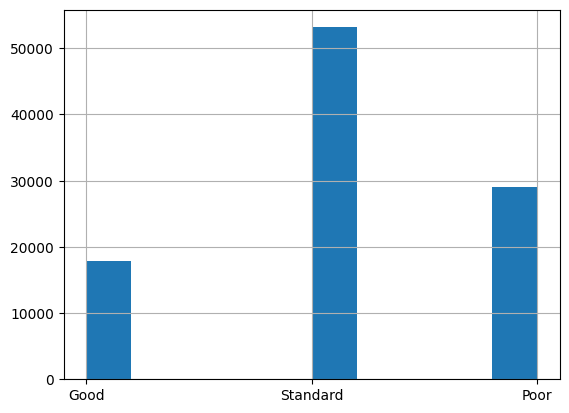

In [10]:
print(data['Credit_Score'].value_counts(normalize=True))
data['Credit_Score'].hist()

O histograma e o value_counts do target revelam que há um desbalanceamento dos dados, de modo que mais da metade dos clientes possuem a classificação de pagador médio, enquanto que menos de 20% são prováveis bons pagadores. Isso revela a importancia de usar estratificação na divisão de treino e teste. Pode-se também realizar o balanceamento dos dados com algumas das ferramentas disponibilizadas pelo python, especialmente o sklearn.

# Divisão dos Dados em Treino e Test

Antes de realizar o pré-processamento dos dados, realizaremos a separação do target das demais colunas e a divisão do data set em treino e teste a fim de evitar qualquer vazamento de dados, o que levaria o modelo a aprender qualquer coisa sobre os dados e teste, compromentendo a eficácia do modelo em produção.

Separação do Target

In [11]:
!pip install scikit-learn

In [12]:
from sklearn.model_selection import train_test_split

X = data.drop(columns="Credit_Score")
Y = data["Credit_Score"]

Particonamento dos dados em treino e teste.

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
X_train

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
10268,0x522a,CUS_0x2dbf,May,Abhishek Vishnoiw,51,370-51-2390,Musician,101583.48,NaN,5,7,10,4_,"Payday Loan, Student Loan, Payday Loan, and Debt Consolidation Loan",8,8,2.89,5.0,Standard,50.93,34.462154,24 Years and 1 Months,No,190.811017,630.0157894388726,Low_spent_Large_value_payments,314.0021934422197
12727,0x6091,CUS_0x8167,August,Freifeldu,23,721-85-0529,Writer,101926.95,8635.912500,4,4,9,1,Mortgage Loan,13,9,10.26,6.0,_,1058.0,39.693812,20 Years and 5 Months,No,70.587681,662.8039273360225,Low_spent_Medium_value_payments,410.1996419555151
30953,0xcb5f,CUS_0x3a0b,February,NaN,49,618-96-2558,Writer,158871.12,NaN,0,4,8,1,Home Equity Loan,8,2,1.17,4.0,Good,576.48,39.367225,19 Years and 0 Months,No,86.905860,746.8059854204569,Low_spent_Medium_value_payments,742.5141542054829
61394,0x17dbc,CUS_0x9a4b,March,Alex Dobuzinskiso,40,817-31-4270,Doctor,60379.28,NaN,5,6,18,3,"Personal Loan, Mortgage Loan, and Credit-Builder Loan",15,12,6.83,1.0,Standard,725.39,29.061701,17 Years and 1 Months,NM,90.906385,166.41865803064803,High_spent_Medium_value_payments,473.13562343490486
90061,0x225b3,CUS_0x253a,June,NaN,17,580-53-4920,Accountant,50050.83,4085.902500,9,10,20,5,"Student Loan, Credit-Builder Loan, Debt Consolidation Loan, Debt Consolidation Loan, and Personal Loan",28,NaN,15.45,8.0,Bad,3419.1,30.386321,4 Years and 6 Months,Yes,190.445060,56.789441169542684,High_spent_Large_value_payments,401.3557486786916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54631,0x15619,CUS_0x21f4,August,Flynnq,55,587-32-3592,Doctor,114597.04,NaN,7,6,4,4,"Auto Loan, Not Specified, Payday Loan, and Student Loan",32,8,10.54,2.0,Good,926.18,26.436313,31 Years and 9 Months,No,225.923762,327.61966834569836,High_spent_Medium_value_payments,633.1319027289683
6534,0x3c48,CUS_0x68a8,July,laise Robinsono,28,517-09-6321,Entrepreneur,8227.855_,656.654583,6,8,31,-100,"Not Specified, Credit-Builder Loan, Credit-Builder Loan, Credit-Builder Loan, Auto Loan, Personal Loan, and Not Specified",61,20,17.6,7.0,_,2695.38,24.127401,11 Years and 8 Months,NM,7352.000000,49.54415830254037,Low_spent_Medium_value_payments,268.10843495889225
21767,0x9589,CUS_0xc52a,August,da Costab,46,601-99-6960,Writer,35032.66,2853.388333,10,6,33,7,"Credit-Builder Loan, Student Loan, Personal Loan, Mortgage Loan, Payday Loan, Payday Loan, and Student Loan",48,18,2.52,10.0,Bad,1789.0,25.086176,11 Years and 5 Months,Yes,150.500097,106.73567925309915,Low_spent_Small_value_payments,318.1030567807077
16212,0x74fe,CUS_0xa955,May,Gabriel Wildauf,42,861-50-3592,Mechanic,129680.28,10643.690000,8,3,5,2,"Mortgage Loan, and Credit-Builder Loan",27,18,16.65,6.0,_,240.27,33.944094,20 Years and 5 Months,NM,114.165609,567.1798727916067,High_spent_Small_value_payments,643.0235177948541


## Pré-processamento de Dados

Algumas colunas do dataset original não possuem valor real para o modelo, como ID, Nome e identificador do Seguro Social. Então crio uma uma função que poderá ser reutilizada para em qualquer dos dataframes deste problema ou não, mesmo já divididos em treino e test. Age é excluída para evitar a introdução de qualquer pre-conceito no modelo.

### Funções de Pré-Processamento


In [14]:
def Drop_Columns (df: pd.DataFrame, columns_drop:list = ['ID', 'Name', 'Age', 'SSN']):
    return df.drop(columns=columns_drop, errors="ignore")


Criei uma função para transformar a coluna Credit_History_Age em float já que seus dados indicam um período em anos na forma de string. Ex.: "17 Years and 1 Months	"

In [15]:
!pip install numpy

In [16]:
import re
import numpy as np
def Convert_String_To_Time(value):
    if not isinstance(value, str):
        return np.nan

    match = re.search(r'(\d+) Years? and (\d+) Months?', value)

    if not match:
        return np.nan

    y, m = match.groups()

    return int(y) + int(m)/12

Algumas colunas que deveriam ser float não o são por causa de um underline após o valor correto. A função abaixo serve para remover.


In [17]:
def Convert_String_To_Float(value):
    if isinstance(value, float): return value

    try:
        return round(float(value.replace('_', '')),2)
    except Exception:
        return np.nan



A Função a seguir é semelhante à primeira, mas aplica-se a coluna Changed_Credit_Limit, em que há alguns dados apenas com um traço, o que pode indicar que não houve mudança no limite de crédito. Então por padrão substitui por zero ou chama a função anterior.

In [18]:
def Convert_String_To_Float_Default_Zero(value):
    if isinstance(value, float): return value

    try:
        if value == '-': return 0
        return Convert_String_To_Float(value)
    except Exception:
        return np.nan

A próxima função aplica as funções anteriores às colunas numéricas.

In [19]:

import re
def Clear_Data_Should_number(df: pd.DataFrame):

  columns_number = [
      'Annual_Income',
      'Num_of_Loan',
      'Num_of_Delayed_Payment',
      'Outstanding_Debt',
      'Amount_invested_monthly',
      'Monthly_Balance',
    ]
  columns_delta = ['Changed_Credit_Limit']
  columns_time_stamp = ['Credit_History_Age']


  df[columns_number + columns_delta + columns_time_stamp]


  for col in columns_number:
    df[col] = df[col].apply(Convert_String_To_Float)
    df[col] = df[col].astype(float)

  for col in columns_delta:
    df[col] = df[col].apply(Convert_String_To_Float_Default_Zero)
    df[col] = df[col].astype(float)

  for col in columns_time_stamp:
    df[col] = df[col].apply(Convert_String_To_Time)
    df[col] = df[col].astype(float)

  print(df.info())

  return df



As funções anteriores não tratam valores nulos. Pra isso usei a função a seguir. Ao invés de simplesmente usar o SimpleImputer, achei que é mais pertinente fazer substituições de valores usando a média dos dados do mesmo cliente.

In [20]:

def Transform_Numericals(df: pd.DataFrame, features_num: list):

    for col in features_num:

        if df[col].isna().any():

            df[col] = df[col].fillna( df.groupby("Customer_ID")[col].transform( lambda x: x.mean()))


            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df



Usei o mesmo raciocínio para as features categóricas, mas aqui uso a moda.

In [21]:
def Transform_Categorical(df: pd.DataFrame, features_cat: list):

    for col in features_cat:

        if df[col].isna().any():

            df[col] = df[col].fillna(
                  df.groupby("Customer_ID")[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
              )


    return df

### Pré-Processamento dos dados de Treino


#### Features Numéricas
Agora aplico a função de limpeza dos dados às variáveis numéricas.

In [22]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np


X_train = Drop_Columns(X_train)

X_train  = Clear_Data_Should_number(X_train)
features_num = X_train.select_dtypes(include=np.number).columns.tolist()


<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 10268 to 92972
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               80000 non-null  object 
 1   Month                     80000 non-null  object 
 2   Occupation                80000 non-null  object 
 3   Annual_Income             80000 non-null  float64
 4   Monthly_Inhand_Salary     67968 non-null  float64
 5   Num_Bank_Accounts         80000 non-null  int64  
 6   Num_Credit_Card           80000 non-null  int64  
 7   Interest_Rate             80000 non-null  int64  
 8   Num_of_Loan               80000 non-null  float64
 9   Type_of_Loan              70843 non-null  object 
 10  Delay_from_due_date       80000 non-null  int64  
 11  Num_of_Delayed_Payment    74405 non-null  float64
 12  Changed_Credit_Limit      78309 non-null  float64
 13  Num_Credit_Inquiries      78451 non-null  float64
 14  Credit_

Aplico em seguida a função própria de tratamento de dados ausentes, os substituindo pela média do próprio cliente. Se ainda assim permanecerem dados ausentes, aplico o SimpleImputer, dessa vez substituindo pela média global.

In [23]:
X_train = Transform_Numericals(df=X_train, features_num=features_num)
num_imputer = SimpleImputer(strategy="mean")
X_train[features_num] = num_imputer.fit_transform(X_train[features_num])



Em seguida, aplico o standardScaler a fim de que o modelo não dê mais importância a uma feature em função dos seus valores mais elevados ou que despreze outra em função de seus baixos valores. O Scaler padroniza os dados.

In [24]:
scaler = StandardScaler()
X_train[features_num] = scaler.fit_transform(X_train[features_num])
X_train[features_num].info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 10268 to 92972
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Annual_Income             80000 non-null  float64
 1   Monthly_Inhand_Salary     80000 non-null  float64
 2   Num_Bank_Accounts         80000 non-null  float64
 3   Num_Credit_Card           80000 non-null  float64
 4   Interest_Rate             80000 non-null  float64
 5   Num_of_Loan               80000 non-null  float64
 6   Delay_from_due_date       80000 non-null  float64
 7   Num_of_Delayed_Payment    80000 non-null  float64
 8   Changed_Credit_Limit      80000 non-null  float64
 9   Num_Credit_Inquiries      80000 non-null  float64
 10  Outstanding_Debt          80000 non-null  float64
 11  Credit_Utilization_Ratio  80000 non-null  float64
 12  Credit_History_Age        80000 non-null  float64
 13  Total_EMI_per_month       80000 non-null  float64
 14  Amount_

#### Features Categóricas
A seguir seleciono as features categóricas.

In [25]:
features_cat = X_train.select_dtypes(exclude=np.number).columns.tolist()
features_cat.remove("Customer_ID")
print(features_cat)


['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


A função Transform_Categorical, definida anteriormente, preence valores ausentes com a moda de cada cliente. Caso ainda  restem valores ausentes, estes são substituídos pela moda global.

In [26]:

X_train = Transform_Categorical(df=X_train, features_cat=features_cat)
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[features_cat] = cat_imputer.fit_transform(X_train[features_cat])


Agora faço a transformação dos dados categóricos em numéricos através do OneHotEncoder, semelhante ao que faz o dummies do pandas. Como resultado, há uma coluna para cada possível valor da featur original. Se o valor orginal era A a coluna que representa essa informação terá o valor 1 e as demais 0.

In [27]:

encoder = OneHotEncoder()
X_train_cat_encoded = encoder.fit_transform(X_train[features_cat])

#### Dados de treino pré-processados
Por fim uso o numpy hstack para juntar dados categóricos e numéricos

In [28]:
X_train_preprocessed = np.hstack((X_train[features_num], X_train_cat_encoded.toarray()))

### Pré-Processamento dos Dados de Teste

In [29]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1923 to 2242
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        20000 non-null  object 
 1   Customer_ID               20000 non-null  object 
 2   Month                     20000 non-null  object 
 3   Name                      18044 non-null  object 
 4   Age                       20000 non-null  object 
 5   SSN                       20000 non-null  object 
 6   Occupation                20000 non-null  object 
 7   Annual_Income             20000 non-null  object 
 8   Monthly_Inhand_Salary     17030 non-null  float64
 9   Num_Bank_Accounts         20000 non-null  int64  
 10  Num_Credit_Card           20000 non-null  int64  
 11  Interest_Rate             20000 non-null  int64  
 12  Num_of_Loan               20000 non-null  object 
 13  Type_of_Loan              17749 non-null  object 
 14  Delay_fro

#### Features Numéricas


In [30]:
X_test = Drop_Columns(X_test)
X_test  = Clear_Data_Should_number(X_test)
X_test = Transform_Numericals(df=X_test, features_num=features_num)
X_test[features_num] = num_imputer.transform(X_test[features_num])
X_test[features_num] = scaler.transform(X_test[features_num])

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1923 to 2242
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               20000 non-null  object 
 1   Month                     20000 non-null  object 
 2   Occupation                20000 non-null  object 
 3   Annual_Income             20000 non-null  float64
 4   Monthly_Inhand_Salary     17030 non-null  float64
 5   Num_Bank_Accounts         20000 non-null  int64  
 6   Num_Credit_Card           20000 non-null  int64  
 7   Interest_Rate             20000 non-null  int64  
 8   Num_of_Loan               20000 non-null  float64
 9   Type_of_Loan              17749 non-null  object 
 10  Delay_from_due_date       20000 non-null  int64  
 11  Num_of_Delayed_Payment    18593 non-null  float64
 12  Changed_Credit_Limit      19600 non-null  float64
 13  Num_Credit_Inquiries      19584 non-null  float64
 14  Credit_Mi

#### Features Categóricas


In [31]:
X_test = Transform_Categorical(df=X_test, features_cat=features_cat)
X_test[features_cat] = cat_imputer.transform(X_test[features_cat])
X_test_cat_encoded = encoder.transform(X_test[features_cat])


In [32]:
X_test_preprocessed = np.hstack((X_test[features_num], X_test_cat_encoded.toarray()))

## SVM

Criei funções para gerar as métricas dos modelos de classificação, a fim de reutilizá-las em cada modelo treinado.

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

def Gerar_Dados(X, Y, estimator):
    y_pred = estimator.predict(X)
    cm = confusion_matrix(X, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap='viridis')
    plt.show()
    print(classification_report(X, y_pred))
    RocCurveDisplay.from_estimator(estimator, X, y_pred)


def Metrics_Classification(estimator, X_train, X_test, Y_train, Y_pred_train):
  print("Métricas de Avaliação de Treino: ")
  Gerar_Dados(X_train, Y_train, estimator)

  print("Métricas de Avaliação de Teste: ")
  Gerar_Dados(X_test, Y_test, estimator)



In [ ]:
from sklearn.svm import SVC, LinearSVC

svm_model = LinearSVC(C=1.0, random_state=42, max_iter=2000)
svm_model.fit(X_train_preprocessed, Y_train)


In [ ]:
Metrics_Classification(svm_model, X_train_preprocessed, X_test_preprocessed, Y_train, Y_test)

### Modelos de Boosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_model = AdaBoostClassifier()
adaboost_model.fit(X_train_preprocessed, Y_train)

Metrics_Classification(adaboost_model, X_train_preprocessed, X_test_preprocessed, Y_train, Y_test)

## Escolha de hiperparâmetros

A fim de utilizar os dois tipos de modelos (SVM e modelos de boosting) criarei um dicionário e um pipeline de treino com os modelos e respectivos hiperparâmetros.

# Treinamento de modelo

# Avaliação de desempenho de modelo